In [1]:
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
new_model = tf.keras.models.load_model(r"C:\Users\Admin\Documents\DROWSINESS DETECTION\drowsiness_model.h5")

checking the network for predictions

In [19]:
image_size = 224
image_array = cv2.imread(r"C:\Users\Admin\Documents\DROWSINESS DETECTION\DATASET\train\sleepy\s0001_00026_0_0_0_0_0_01.png", cv2.IMREAD_GRAYSCALE)
backtorgb = cv2.cvtColor(image_array, cv2.COLOR_GRAY2RGB)
new_array = cv2.resize(backtorgb, (image_size, image_size))

In [24]:
X_input = np.array(new_array).reshape(1, image_size, image_size, 3)

In [25]:
X_input.shape

(1, 224, 224, 3)

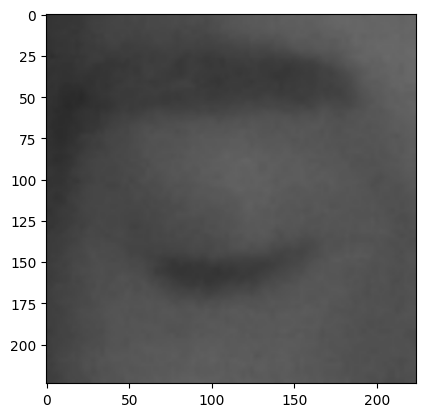

In [26]:
plt.imshow(new_array)

In [23]:
X_input = X_input/255.0

In [27]:
prediction = new_model.predict(X_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [28]:
prediction

array([[0.9526774]], dtype=float32)

Let check on unknown images

In [29]:
image = cv2.imread(r"C:\Users\Admin\Documents\DROWSINESS DETECTION\images.jpeg")

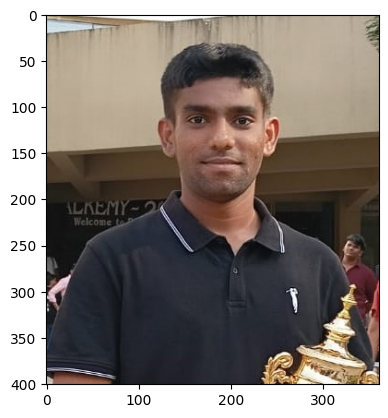

In [30]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

In [31]:
import os

path = r"C:\Users\Admin\Documents\DROWSINESS DETECTION\haarcascade_frontalface_default.xml"

print(os.path.exists(path))  # True aana chahiye

faceCascade = cv2.CascadeClassifier(path)

True


In [32]:
import os

path = r"C:\Users\Admin\Documents\DROWSINESS DETECTION\haarcascade_eye_tree_eyeglasses.xml"

print(os.path.exists(path))  # True aana chahiye

eye_cascade = cv2.CascadeClassifier(path)

True


In [33]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [34]:
eyes = eye_cascade.detectMultiScale(gray,1.1,4)

In [35]:
for (x, y, w, h) in eyes:
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

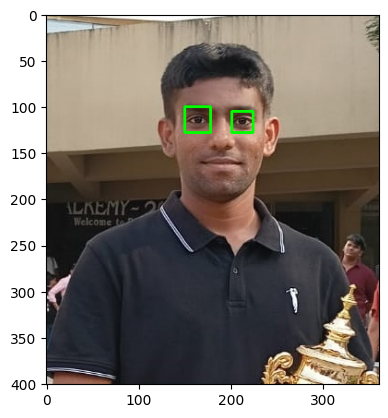

In [36]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

cropping the eye image

In [39]:
import os
path = r"C:\Users\Admin\Documents\DROWSINESS DETECTION\haarcascade_eye_tree_eyeglasses.xml"
eye_cascade = cv2.CascadeClassifier(path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
eyes = eye_cascade.detectMultiScale(gray,1.1,4)
for x,y,w,h in eyes:
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = image[y:y+h, x:x+w]
    eyess = eye_cascade.detectMultiScale(roi_gray)
    if len(eyess) == 0:
        print("Eyes are not detected")
    else:
        for (ex,ey,ew,eh) in eyess:
            eyes_roi = roi_color[ey: ey+eh, ex:ex + ew]

Eyes are not detected


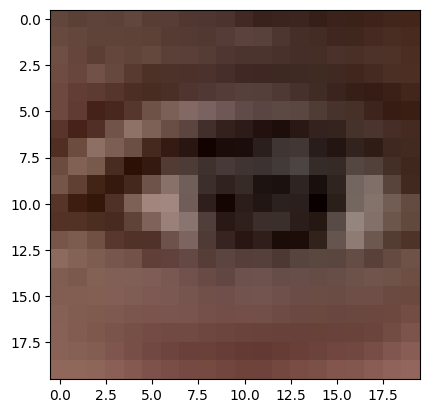

In [40]:
plt.imshow(cv2.cvtColor(eyes_roi, cv2.COLOR_BGR2RGB))

In [41]:
eyes_roi.shape

(20, 20, 3)

In [42]:
final_image = cv2.resize(eyes_roi, (224,224))
final_image = np.expand_dims(final_image, axis=0)
final_image = final_image/255.0

In [43]:
final_image.shape

(1, 224, 224, 3)

In [44]:
new_model.predict(final_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step


array([[0.63807356]], dtype=float32)

Live video demo code 

In [2]:
import cv2
import numpy as np

# ================== CASCADE FILES ==================
face_path = r"C:\Users\Admin\Documents\DROWSINESS DETECTION\haarcascade_frontalface_default.xml"
eye_path = r"C:\Users\Admin\Documents\DROWSINESS DETECTION\haarcascade_eye_tree_eyeglasses.xml"

face_cascade = cv2.CascadeClassifier(face_path)
eye_cascade = cv2.CascadeClassifier(eye_path)

# ================== CAMERA SETUP ==================
def start_camera():
    for i in range(5):  # try more indexes
        print(f"Trying camera index {i}...")
        cap = cv2.VideoCapture(i)

        if cap is not None and cap.isOpened():
            print(f"✅ Camera opened at index {i}")
            return cap

    return None  # IMPORTANT

cap = start_camera()

# ❌ STOP if camera not found
if cap is None:
    print("❌ No camera found. Fix this first!")
    sys.exit()

# ================== MAIN LOOP ==================
while True:
    ret, frame = cap.read()

    if not ret or frame is None:
        print("❌ Frame not captured")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes_roi = None

    # ================== EYE DETECTION ==================
    eyes = eye_cascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in eyes:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        eyes_roi = frame[y:y+h, x:x+w]

    # ================== PREDICTION ==================
    if eyes_roi is not None:
        try:
            final_image = cv2.resize(eyes_roi, (224, 224))
            final_image = np.expand_dims(final_image, axis=0)
            final_image = final_image / 255.0

            prediction = new_model.predict(final_image, verbose=0)

            if prediction[0][0] > 0.5:
                status = "Open Eyes / Awake"
                color = (0, 255, 0)
            else:
                status = "Closed Eyes / Sleepy"
                color = (0, 0, 255)

        except Exception as e:
            print("Prediction error:", e)
            status = "Error"
            color = (0, 0, 255)
    else:
        status = "No Eyes Detected"
        color = (255, 0, 0)

    # ================== FACE DETECTION ==================
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # ================== DISPLAY ==================
    cv2.putText(frame,
                status,
                (30, 50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                color,
                2)

    cv2.imshow("Drowsiness Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Trying camera index 0...
Trying camera index 1...
Trying camera index 2...
Trying camera index 3...
Trying camera index 4...
❌ No camera found. Fix this first!


SystemExit: 

C:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3534: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


beeping sound

In [5]:
import winsound
import numpy as np
import cv2

# ================== SOUND ==================
frequency = 2500
duration = 1000

# ================== CASCADE LOAD ==================
face_path = r"C:\Users\Admin\Documents\DROWSINESS DETECTION\haarcascade_frontalface_default.xml"
eye_path = r"C:\Users\Admin\Documents\DROWSINESS DETECTION\haarcascade_eye_tree_eyeglasses.xml"

faceCascade = cv2.CascadeClassifier(face_path)
eye_cascade = cv2.CascadeClassifier(eye_path)

# ================== CAMERA ==================
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    cap = cv2.VideoCapture(1)
if not cap.isOpened():
    raise IOError("Cannot open your camera")

counter = 0

# ================== LOOP ==================
while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes_roi = None  # important

    # ================== EYE DETECTION ==================
    eyes = eye_cascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in eyes:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        eyes_roi = frame[y:y+h, x:x+w]

    # ================== FACE DETECTION ==================
    faces = faceCascade.detectMultiScale(gray, 1.1, 4)
    for (fx, fy, fw, fh) in faces:
        cv2.rectangle(frame, (fx, fy), (fx+fw, fy+fh), (255, 0, 0), 2)

    font = cv2.FONT_HERSHEY_SIMPLEX

    # ================== PREDICTION ==================
    if eyes_roi is not None:
        try:
            final_image = cv2.resize(eyes_roi, (224, 224))
            final_image = np.expand_dims(final_image, axis=0)
            final_image = final_image / 255.0

            # 👉 MODEL already loaded in previous cell
            prediction = new_model.predict(final_image, verbose=0)

            if prediction[0][0] > 0.5:
                status = "Open Eyes / Awake"
                counter = 0

                cv2.putText(frame, status, (150, 150), font, 1.2, (0, 255, 0), 2)

                cv2.rectangle(frame, (0, 0), (200, 70), (0,0,0), -1)
                cv2.putText(frame, 'Active', (20, 45), font, 0.7, (0,255,0), 2)

            else:
                status = "Closed Eyes / Sleepy"
                counter += 1

                cv2.putText(frame, status, (150, 150), font, 1.2, (0, 0, 255), 2)

                # 🔊 ALERT LOGIC
                if counter > 5:
                    cv2.rectangle(frame, (0, 0), (250, 70), (0,0,0), -1)
                    cv2.putText(frame, 'SLEEP ALERT!!', (20, 45), font, 0.7, (0,0,255), 2)

                    winsound.Beep(frequency, duration)

                    counter = 0

        except Exception as e:
            print("Prediction Error:", e)

    else:
        cv2.putText(frame, "No Eyes Detected", (150, 150), font, 1.2, (255, 0, 0), 2)

    # ================== DISPLAY ==================
    cv2.imshow('Drowsiness Detection Tutorial', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

OSError: Cannot open your camera